[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/navjotts/ML-experiments/blob/master/21%20-%20Comparing%20clustering%20algorithms/Comparing_clustering_algorithms.ipynb)

## Data

We'll be using one of the UCI datasets: 
http://scikit-learn.org/stable/modules/classes.html#module-sklearn.datasets

In [0]:
from time import time
import numpy as np
import matplotlib.pyplot as plt

from sklearn import metrics
from sklearn.cluster import KMeans
from sklearn.datasets import load_wine
from sklearn.decomposition import PCA

In [3]:
wine_dataset = load_wine()
data = wine_dataset.data
labels = wine_dataset.target

n_samples, n_features = data.shape
n_clusters = len(np.unique(labels))

print("n_clusters: %d, \t n_samples %d, \t n_features %d" % (n_clusters, n_samples, n_features))

n_clusters: 3, 	 n_samples 178, 	 n_features 13


## Benchmarking (for KMeans)

In [0]:
def benchmark_clustering(estimator, name, data, labels):
  t0 = time()
  estimator.fit(data)
  print("%-9s\t%0.2f\t%i\t%0.3f\t%0.3f\t%0.3f\t%0.3f\t%0.3f\t%0.3f" %
        (name,
        time()-t0,
        estimator.inertia_,
        metrics.homogeneity_score(labels, estimator.labels_),
        metrics.completeness_score(labels, estimator.labels_),
        metrics.v_measure_score(labels, estimator.labels_),
        metrics.adjusted_rand_score(labels, estimator.labels_),
        metrics.adjusted_mutual_info_score(labels, estimator.labels_),
        metrics.silhouette_score(data, estimator.labels_, metric='euclidean', sample_size=300)))

In [5]:
print(100 * '_')
print('init\t\ttime\tinertia\thomo\tcompl\tv-meas\tARI\tAMI\tsilhouette')

benchmark_clustering(KMeans(init='k-means++', n_clusters=n_clusters, n_init=10), 
                     'k-means++', 
                     data, 
                     labels)

benchmark_clustering(KMeans(init='random', n_clusters=n_clusters, n_init=10), 
                     'random', 
                     data, 
                     labels)

pca = PCA(n_components=n_clusters).fit(data)
benchmark_clustering(KMeans(init=pca.components_, n_clusters=n_clusters, n_init=1), 
                     'PCA-based', 
                     data, 
                     labels)

print(100 * '_')

____________________________________________________________________________________________________
init		time	inertia	homo	compl	v-meas	ARI	AMI	silhouette
k-means++	0.04	2370689	0.429	0.429	0.429	0.371	0.423	0.571
random   	0.02	2370689	0.429	0.429	0.429	0.371	0.423	0.571
PCA-based	0.01	2633555	0.399	0.451	0.423	0.352	0.392	0.560
____________________________________________________________________________________________________


## Visualize in 2D

### Reduce the dimension to 2, and visualize the clustering in 2D

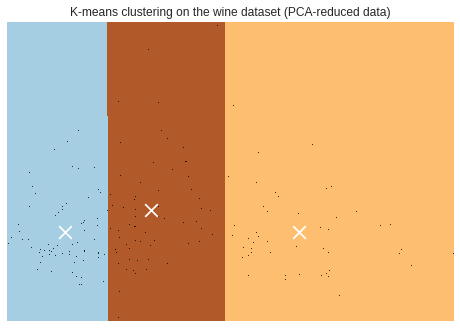

In [9]:
reduced_data = PCA(n_components=2).fit_transform(data)
kmeans = KMeans(init='k-means++', n_clusters=n_clusters, n_init=10)
kmeans.fit(reduced_data)

# step size of the meshgrid (decrease to increase the quality)
h = 0.05

x_min, x_max = reduced_data[:, 0].min()-1, reduced_data[:, 0].max()+1
y_min, y_max = reduced_data[:, 1].min()-1, reduced_data[:, 1].max()+1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# obtain labels for each point in mesh
Z = kmeans.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(1)
plt.clf()
plt.imshow(Z, 
           interpolation='nearest', 
           extent=(xx.min(), xx.max(), yy.min(), yy.max()), 
           cmap=plt.cm.Paired, 
           aspect='auto', 
           origin='lower')

plt.plot(reduced_data[:, 0], reduced_data[:, 1], 'k.', markersize=2)

# plot the centroids as a white X
centroids = kmeans.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1], marker='x', s=160, linewidths=3, color='w', zorder=10)

plt.title("K-means clustering on the wine dataset (PCA-reduced data)")
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.xticks([])
plt.yticks([])
plt.show();

### Effect of normalization as a pre-processing step

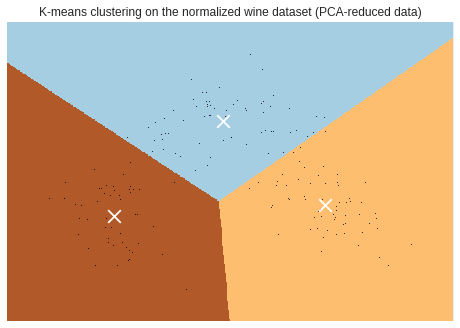

In [10]:
from sklearn.preprocessing import StandardScaler

normalized_data = StandardScaler().fit_transform(data)
reduced_data = PCA(n_components=2).fit_transform(normalized_data)
kmeans = KMeans(init='k-means++', n_clusters=n_clusters, n_init=10)
kmeans.fit(reduced_data)

# step size of the meshgrid (decrease to increase the quality)
h = 0.02

x_min, x_max = reduced_data[:, 0].min()-1, reduced_data[:, 0].max()+1
y_min, y_max = reduced_data[:, 1].min()-1, reduced_data[:, 1].max()+1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# obtain labels for each point in mesh
Z = kmeans.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(1)
plt.clf()
plt.imshow(Z, 
           interpolation='nearest', 
           extent=(xx.min(), xx.max(), yy.min(), yy.max()), 
           cmap=plt.cm.Paired, 
           aspect='auto', 
           origin='lower')

plt.plot(reduced_data[:, 0], reduced_data[:, 1], 'k.', markersize=2)

# plot the centroids as a white X
centroids = kmeans.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1], marker='x', s=160, linewidths=3, color='w', zorder=10)

plt.title("K-means clustering on the normalized wine dataset (PCA-reduced data)")
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.xticks([])
plt.yticks([])
plt.show();

## Clustering algorithms comparison

In [0]:
from time import time
import warnings
import numpy as np
import matplotlib.pyplot as plt
from sklearn import cluster, mixture
from sklearn.neighbors import kneighbors_graph
from itertools import cycle, islice
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

def compare_clustering_algorithms(X, y):
  # normalize dataset for easier parameter selection
  X = StandardScaler().fit_transform(X)  
  
  # bring down the dimension to 2D for plotting
  X = PCA(n_components=2).fit_transform(X)
  
  # setup plot settings
  plt.figure(figsize=(9 * 2 + 3, 2))
  plt.subplots_adjust(left=0.02, right=0.98, bottom=0.01, top=0.96, wspace=0.05, hspace=0.01)  
  plot_num = 1
  
  # setup cluster parameters
  params = {'quantile': 0.3,
            'eps': 0.6,
            'damping': 0.9,
            'preference': -200,
            'n_neighbors': 2,
            'n_clusters': 3}  
    
  # estimate bandwidth for mean shift
  bandwidth = cluster.estimate_bandwidth(X, quantile=params['quantile'])
  
  # connectivity matrix for Structured Ward
  connectivity = kneighbors_graph(X, n_neighbors=params['n_neighbors'], include_self=False)
  connectivity = 0.5*(connectivity + connectivity.T)
  
  # create cluster objects
  ms = cluster.MeanShift(bandwidth=bandwidth, bin_seeding=True)
  
  two_means = cluster.KMeans(n_clusters=params['n_clusters'])
  
  ward = cluster.AgglomerativeClustering(n_clusters=params['n_clusters'], linkage='ward', connectivity=connectivity)
  
  spectral = cluster.SpectralClustering(n_clusters=params['n_clusters'], eigen_solver='arpack', affinity='nearest_neighbors')
  
  dbscan = cluster.DBSCAN(eps=params['eps'])
  
  affinity_propagation = cluster.AffinityPropagation(damping=params['damping'], preference=params['preference'])
  
  average_linkage = cluster.AgglomerativeClustering(n_clusters=params['n_clusters'], linkage='average', affinity='cityblock', connectivity=connectivity)
  
  birch = cluster.Birch(n_clusters=params['n_clusters'])
  
  gmm = mixture.GaussianMixture(n_components=params['n_clusters'], covariance_type='full')
  
  clustering_algorithms = (
    ('KMeans', two_means),
    ('AffinityPropagation', affinity_propagation),
    ('MeanShift', ms),
    ('SpectralClustering', spectral),
    ('Ward', ward),
    ('AgglomerativeClustering', average_linkage),
    ('DBSCAN', dbscan),
    ('Birch', birch),
    ('GaussianMixture', gmm))
  
  for name, algorithm in clustering_algorithms:    
    t0 = time()
    
    # catch warnings related to kneighbors_graph
    with warnings.catch_warnings():
      warnings.filterwarnings(
        "ignore", 
         message="the number of connected components of the connectivity matrix is [0-9]{1,2} > 1. Completing it to avoid stopping the tree early.",
         category=UserWarning)
      warnings.filterwarnings(
        "ignore", 
         message="Graph is not fully connected, spectral embedding may not work as expected.",
         category=UserWarning)
      algorithm.fit(X)
    
    t1 = time()
        
    if hasattr(algorithm, 'labels_'):      
      y_pred = algorithm.labels_.astype(np.int)
    else:      
      y_pred = algorithm.predict(X)
        
    plt.subplot(1, len(clustering_algorithms), plot_num)
    
    plt.title(name, size=18)
    
    colors = np.array(list(islice(cycle(['#377eb8', 
                                         '#ff7f00', 
                                         '#4daf4a', 
                                         '#f781bf', 
                                         '#a65628', 
                                         '#984ea3', 
                                         '#999999', 
                                         '#e41a1c', 
                                         '#dede00']), 
                                  int(max(y_pred)+1))))
    
    plt.scatter(X[:, 0], X[:, 1], s=10, color=colors[y_pred])
    plt.xticks([])
    plt.yticks(())
    plt.text(0.99, 
             .01, 
             ('%0.2f' % (t1-t0)).lstrip('0'), 
             transform=plt.gca().transAxes,
             size=15,
             horizontalalignment='right')
    plot_num += 1
  
  plt.show()    

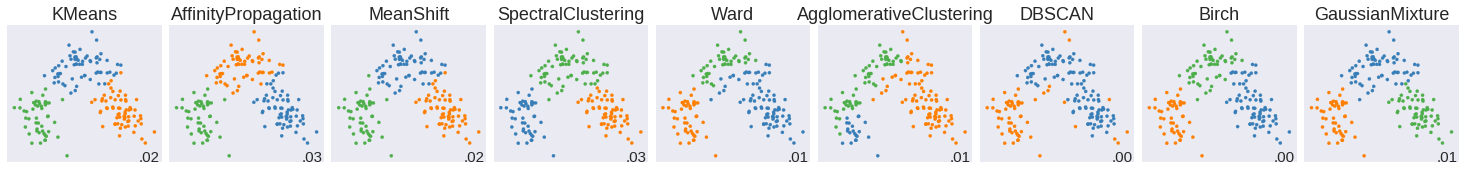

In [14]:
compare_clustering_algorithms(data, labels)

**Observation:** DBScan performs the worst, only able to predict 2 clusters instead of the usual 3 predicted by others